Catherine Carmosino

11/15/2025


# Loading in the Data

In [50]:
#the package imports we need
import hisepy
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [2]:
#importing the data file
h5ad_files = hisepy.cache_fileset('f48bf688-1a5f-456c-b0b0-c6ec870ec003')

In [3]:
#looking at the first 5 file names
h5ad_files[0:5]

['/home/workspace/input/1784782472/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Afatinib_BIBW2992_counts_filtered_labeled_sampled.h5ad',
 '/home/workspace/input/1784782472/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Afatinib_dimaleate_counts_filtered_labeled_sampled.h5ad',
 '/home/workspace/input/1784782472/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Baricitinib_LY3009104_INCB028050_counts_filtered_labeled_sampled.h5ad',
 '/home/workspace/input/1784782472/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Baricitinib_phosphate_counts_filtered_labeled_sampled.h5ad',
 '/home/workspace/input/1784782472/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Canertinib_CI-1033_counts_filtered_labeled_sampled.h5ad']

In [4]:
#creating a list
adata_list = []

#looping through the file names
for h5ad_file in h5ad_files:
    #read the file into an AnnData object using scanpy
    adata = sc.read_h5ad(h5ad_file)
    #appending the AnnData file into the list
    adata_list.append(adata)

In [5]:
#looking at the first 2 AnnData objects in the list
adata_list[0:2]

[AnnData object with n_obs × n_vars = 25000 × 1916
     obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2'
     uns: 'drug_name_colors', 'leiden_2', 'neighbors', 'pca', 'umap'
     obsm: 'X_pca', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 25000 × 1916
     obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2'
     uns: 'drug_name_colors', 'leiden_2', 'neighbors', 'pca', 'umap'
     obsm: 'X_pca', 'X_um

In [6]:
#seeing how many data are in the list (it's 18: 8 drugs with 2 formulas and 2 controls)
len(adata_list)

18

In [7]:
#concatenating/combining all of the AnnData objects into one
adata = sc.concat(adata_list)
adata = adata[adata.obs.AIFI_L2 != "CD8aa"]

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/anndata/_core/merge.py:1667: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(


In [8]:
adata

View of AnnData object with n_obs × n_vars = 449975 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2'
    obsm: 'X_pca', 'X_umap'

**From concatenating, there are 450,000 obersvations.**

**There are 25,000 cells per sample and 18 samples =  450,000 obersvations**

**There are 1,916 genes**

In [9]:
#creating a copy of the data above so any manipulations done won't affect the original data
obs = adata.obs.copy()

In [10]:
#assigning a variable and getting the drug name and AIFI_L2 columns
count_types_per_treatment = obs[['drug_name', 'AIFI_L2']].value_counts()
count_types_per_treatment

drug_name                AIFI_L2  
Erlotinib                CD4 Naive    7335
Afatinib dimaleate       CD4 Naive    6949
Erlotinib Hydrochloride  CD4 Naive    6739
IL6 Control              CD4 Naive    6692
Gefitinib hydrochloride  CD4 Naive    6692
                                      ... 
NVP-BSK805 2HCl          MAIT          441
Erlotinib Hydrochloride  MAIT          439
Afatinib dimaleate       MAIT          426
Baricitinib phosphate    MAIT          425
Erlotinib                MAIT          420
Name: count, Length: 144, dtype: int64

In [11]:
#storing the names of the 1,916 genes in a dataset
adata.var_names

Index(['LAP3', 'CD99', 'CASP10', 'CD38', 'CREBBP', 'ITGAL', 'ITGA3', 'LAMP2',
       'ITGA2B', 'CX3CL1',
       ...
       'PLEKHM1', 'PRAF2', 'CEBPA', 'TWF2', 'HOXA10', 'CHMP4A', 'POLG2',
       'RBM15B', 'DUSP14', 'PIP4K2B'],
      dtype='object', length=1916)

# Scanpy Preprocessing and Clustering

## Normalization

In [12]:
#rescaling each cell to a specific library size
sc.pp.normalize_total(adata, target_sum = 1e4)
#applying a log-transform to the data
sc.pp.log1p(adata)

#sc.pp.scale(adata)
#this was causing issues, the sc.pp.highly_variable_genes runs on normalized, log-transformed, unscaled data.

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


The 3 steps above (normalization, log-transformation, and centering) ensures that all of the genes are on a similar scale. Having all the genes on a similar scale prevents any highly expressed genes from affecting or skewing downstream analysis. 

In [13]:
import re

unique_drug_names = adata.obs['drug_name'].unique()

def clean_name(name):
    name = re.sub(' \\(.*\\) ', ' ', name)
    name = re.sub(' \\(.*\\)$', '', name)
    return name

# for name in unique_drug_names:
#     print(clean_name(name))

adata.obs['clean_drug_name'] = adata.obs['drug_name'].copy().apply(clean_name)

## Feature Selection

`pp.highly_variable_genes` annotates highly variable genes.

### Selecting top 500 genes

In [14]:
#getting the top 500 genes
sc.pp.highly_variable_genes(adata, n_top_genes=500, batch_key="drug_name")

Checking if it reportaed 500 genes: it's a good check to know that the n_top_genes actually gives us x amount of genes

In [15]:
#checking to see how many highly variable genes were selected 
print(f"Number of highly variable genes: {adata.var['highly_variable'].sum()}")

Number of highly variable genes: 500


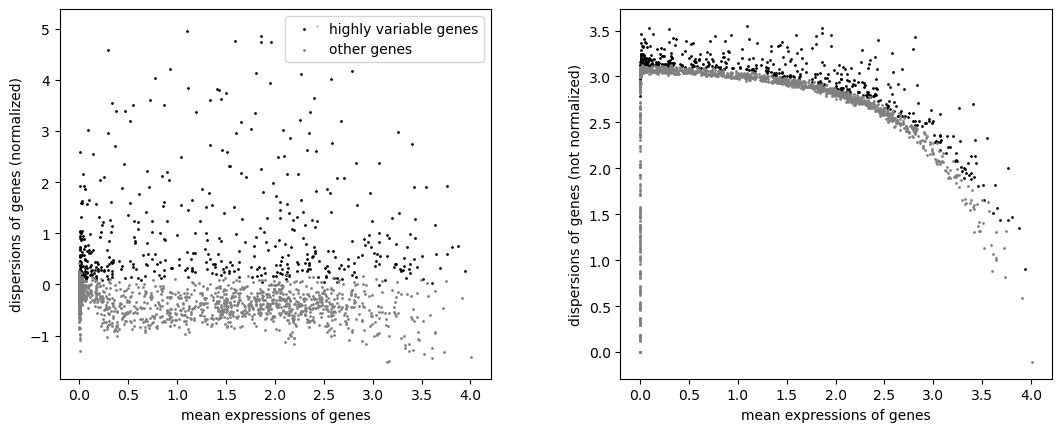

In [16]:
#plotting the top 500 genes
sc.pl.highly_variable_genes(adata)

### Selecting top x amount of genes based on several paramaters

In [17]:
#trying to get highly variable genes by using parameters
sc.pp.highly_variable_genes(adata, min_mean=0.0125, min_disp=0.1, batch_key="drug_name")

In [18]:
#checking to see how many highly variable genes were selected 
print(f"Number of highly variable genes: {adata.var['highly_variable'].sum()}")

Number of highly variable genes: 410


**Looks like with these parameters (min mean and mean dispersion) there are a good amount of highly variable genes: 410**

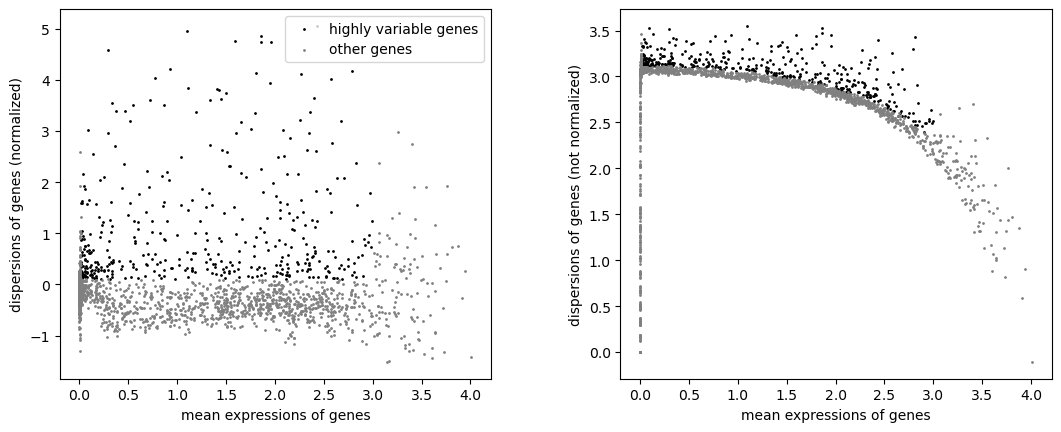

In [19]:
#plotting the top 410 genes
sc.pl.highly_variable_genes(adata)

In [20]:
#keeping only the highly variable genes
adata = adata[:, adata.var.highly_variable].copy()

In [21]:
adata

AnnData object with n_obs × n_vars = 449975 × 410
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'clean_drug_name'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg'
    obsm: 'X_pca', 'X_umap'

**Verified that it kept only 410 genes (out of 1,916 genes) but there are still 450,000 obersvations.**

**There are still 25,000 cells per sample and 18 samples =  450,000 obersvations**

In [22]:
#scaling the data to use for dimensionality reduction
sc.pp.scale(adata, max_value=10)

/home/workspace/environment/pythonscrna12/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


## Dimensionality Reduction: PCA

In [23]:
#reduce the data's dimensionality
sc.tl.pca(adata)

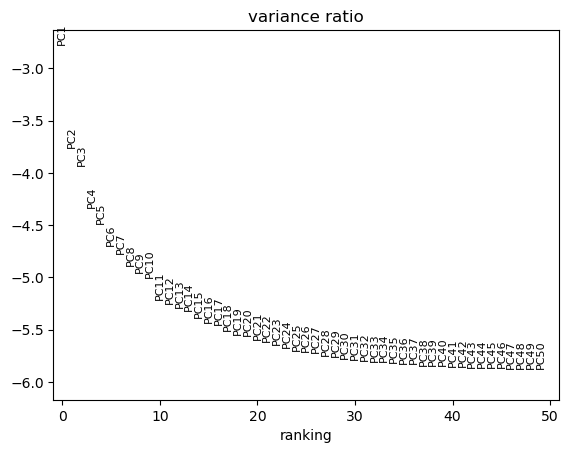

In [24]:
#plotting the pca variance ratio
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

### Looking at PCA 1 vs 2

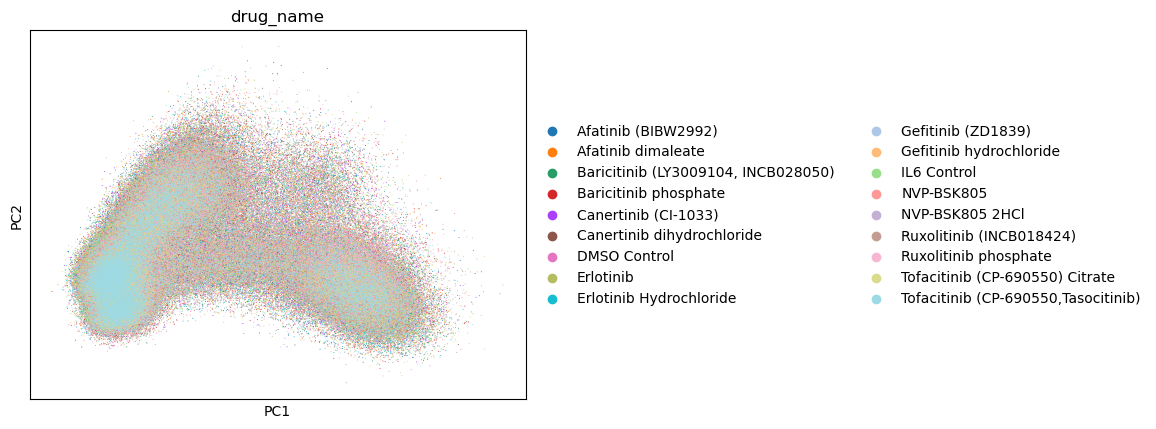

In [25]:
#creating pca plot of pca 1 and 2 based on drug name
sc.pl.pca(
    adata,
    color = ["drug_name"],
    dimensions=[(0, 1)],
    ncols=2,
    size=2
)

**There are not many clear clusters, there are too many drug samples. Will look at the cell type.**

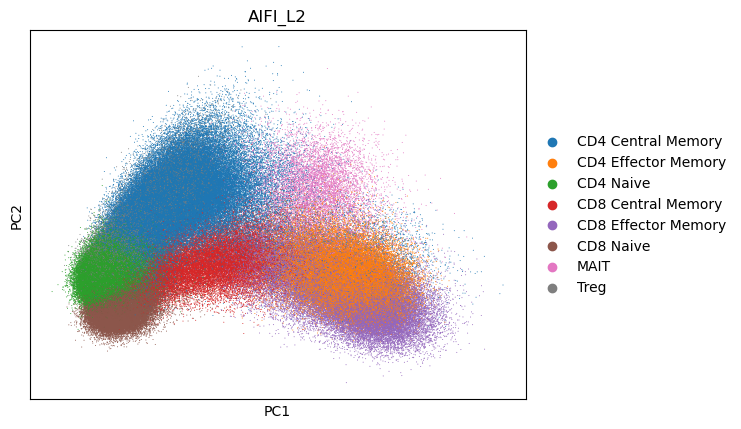

In [26]:
#creating pca plot of pca 1 and 2 based on AIFI_L2 (cell type)
sc.pl.pca(
    adata,
    color = ["AIFI_L2"],
    dimensions=[(0, 1)],
    ncols=2,
    size=2
)

**There are clear clusters from the cell types!**

### Looking at PCA 3 vs 4

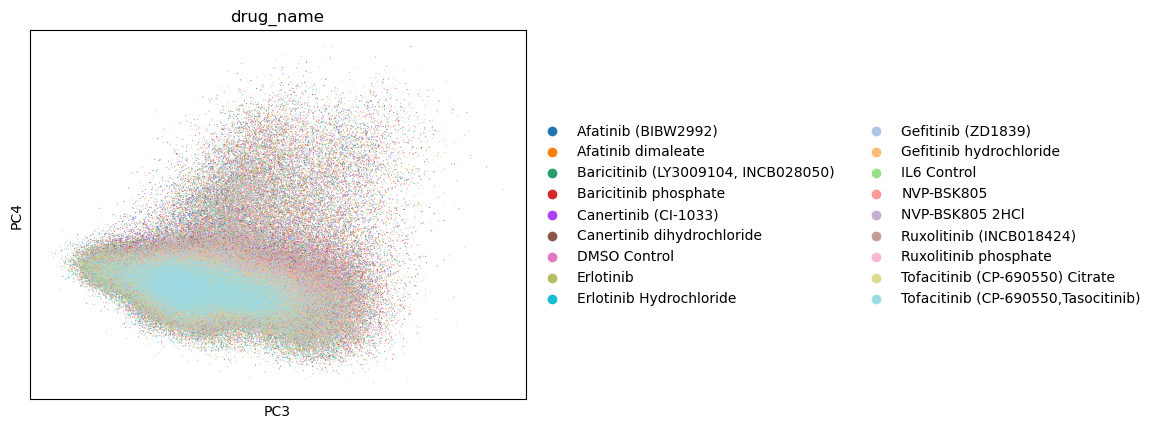

In [27]:
#creating pca plot of pca 3 and 4 based on drug name
sc.pl.pca(
    adata,
    color = ["drug_name"],
    dimensions=[(2, 3)],
    ncols=2,
    size=2
)

**There are less clusters seen here compared to PCA 1 vs 2. There are also so many drug types that there are no colored clusters either. Look at the cell types:**

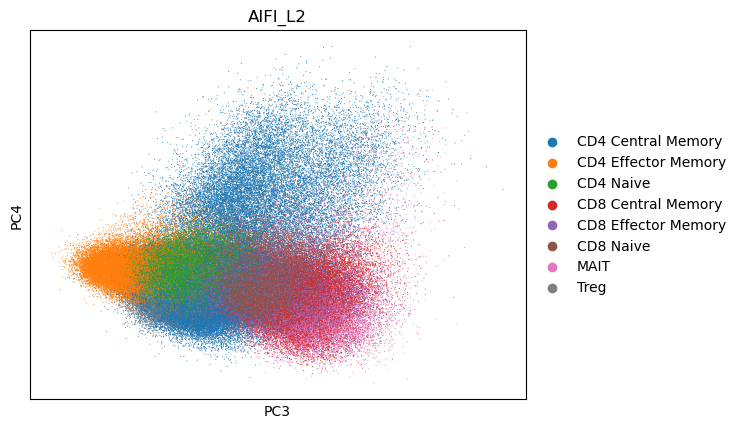

In [28]:
#creating pca plot of pca 3 and 4 based on AIFI_L2 (cell type)
sc.pl.pca(
    adata,
    color = ["AIFI_L2"],
    dimensions=[(2, 3)],
    ncols=2,
    size=2
)

**There are some cell type clusters, less clear compared to PCA 1 vs 2.**

## Dimensionality Reduction: UMAPs
### Nearest neighbor graph construction and visualization: UMAP!

In [29]:
#calculating a neighborhood graph of observations based on similarity
sc.pp.neighbors(adata) #n_neighbors=15, n_pcs=30

In [30]:
#reduceing the dimensionality of the data to plot with UMAP
sc.tl.umap(adata)

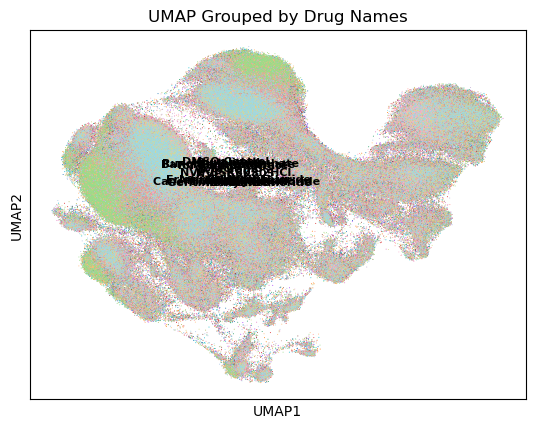

In [61]:
#plotting a UMAP using the drug names
sc.pl.umap(
    adata,
    color="clean_drug_name",
    size=2,
    title="UMAP Grouped by Drug Names",
    legend_loc="on data", 
    legend_fontsize=8,
    save="_drug_name_on_data.png"
)

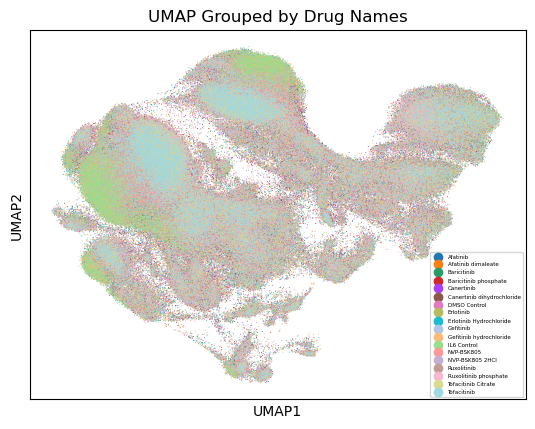

In [72]:
#plotting a UMAP using the drug names
ax = sc.pl.umap(
    adata,
    color="clean_drug_name",
    size=2,
    title="UMAP Grouped by Drug Names", 
    legend_loc="best", 
    legend_fontsize=4,
    show=False
)

ax.figure.savefig(
    "umap_drug_name_inside.png",
    dpi=300,
    bbox_inches="tight"
)

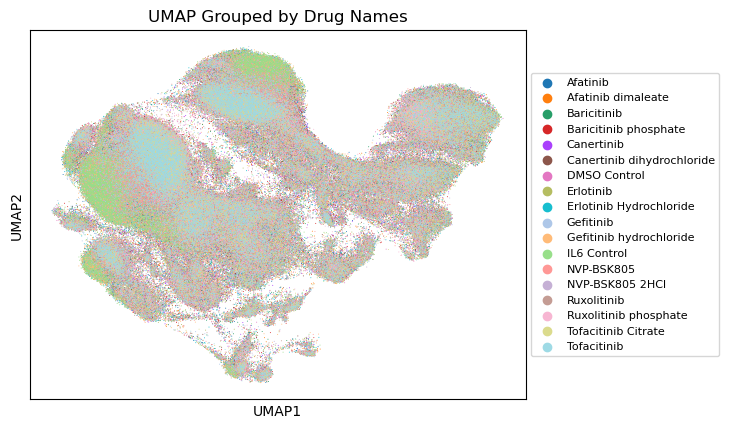

In [70]:
ax = sc.pl.umap(
    adata,
    color="clean_drug_name",
    size=2,
    title="UMAP Grouped by Drug Names",
    legend_fontsize=8,
    legend_loc="right",
    show=False
)

legend = ax.get_legend()

# Force single column
legend._ncols = 1

# Move legend outside
legend.set_bbox_to_anchor((1, 0.5))
legend.set_loc("center left")

ax.figure.savefig(
    "umap_drug_name_legend_right.png",
    dpi=300,
    bbox_inches="tight"
)


**Similar to PCA plots, too many drug names to see clear colored-clusters. However, there are some physically apparent clusters.** 

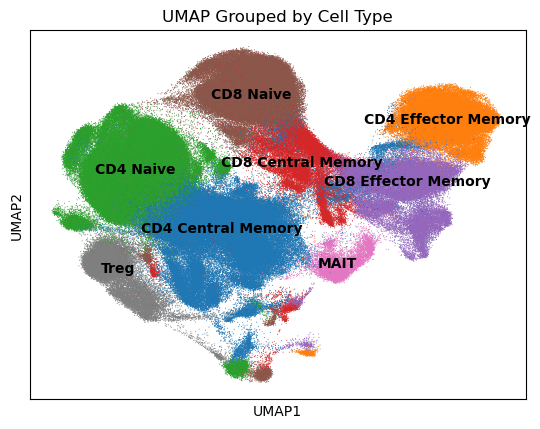

In [73]:
#plotting a UMAP using AIFI_L2 (cell type) 
ax = sc.pl.umap(
    adata,
    color="AIFI_L2",
    size=2,
    title="UMAP Grouped by Cell Type",
    legend_loc="on data", 
    show = False
)

ax.figure.savefig(
    "umap_cell_type_on_data.png",
    dpi=300,
    bbox_inches="tight"
)

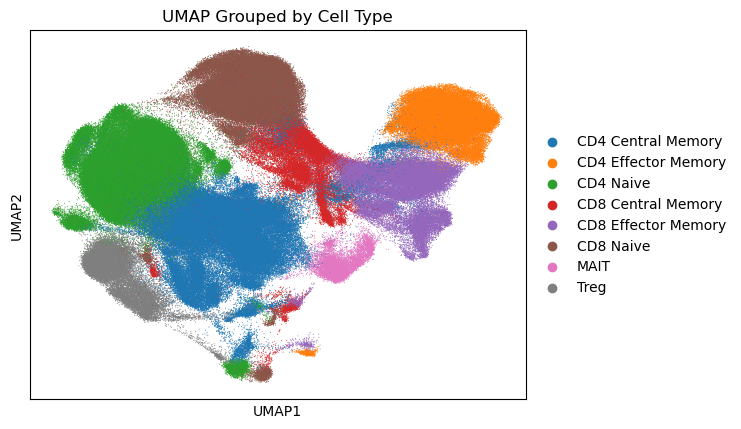

In [74]:
#plotting a UMAP using AIFI_L2 (cell type) 
ax = sc.pl.umap(
    adata,
    color="AIFI_L2",
    size=2,
    title="UMAP Grouped by Cell Type",
    show = False
)

ax.figure.savefig(
    "umap_cell_type_right.png",
    dpi=300,
    bbox_inches="tight"
)

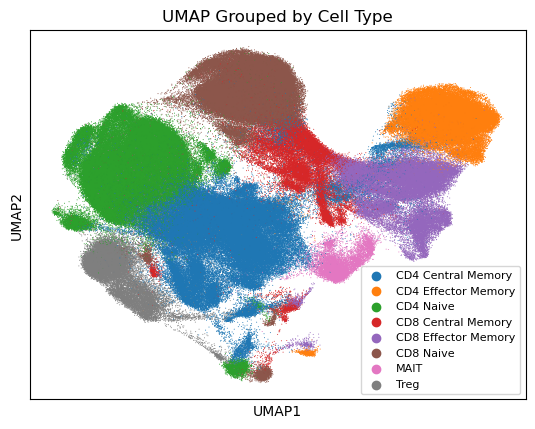

In [75]:
#plotting a UMAP using AIFI_L2 (cell type) 
ax = sc.pl.umap(
    adata,
    color="AIFI_L2",
    size=2,
    title="UMAP Grouped by Cell Type",
    legend_loc="best", 
    legend_fontsize=8,
    show = False
)

ax.figure.savefig(
    "umap_cell_type_inside.png",
    dpi=300,
    bbox_inches="tight"
)


**Similar to PCA plots, using cell types colored and grouped the clusters very well.** 